# Modified Architecture Trained on Fashion MNIST

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # Flatten to 784
])

train_dataset_fmnist = datasets.FashionMNIST(root='./data_FMNIST', train=True, download=True, transform=transform)
test_dataset_fmnist = datasets.FashionMNIST(root='./data_FMNIST', train=False, download=True, transform=transform)

train_loader_fmnist = DataLoader(train_dataset_fmnist, batch_size=100, shuffle=True)
test_loader_fmnist = DataLoader(test_dataset_fmnist, batch_size=100, shuffle=False)

In [3]:
class TargetPropAutoencoder_V2(nn.Module):
    def __init__(self, input_dim=784, hidden1a=1000, hidden1b=500, hidden2=150):
        super().__init__()
        # Encoder
        self.enc1a = nn.Linear(input_dim, hidden1a)
        self.enc1b = nn.Linear(hidden1a, hidden1b)
        self.enc2 = nn.Linear(hidden1b, hidden2)

        # Decoder
        self.dec2 = nn.Linear(hidden2, hidden1b)
        self.dec1b = nn.Linear(hidden1b, hidden1a)
        self.dec1a = nn.Linear(hidden1a, input_dim)

        # Activations
        self.relu = nn.ReLU()
        self.softplus = nn.Softplus()
        self.sigmoid = nn.Sigmoid()

    # Encoder path
    def F1(self, x):
        h1a = self.relu(self.enc1a(x))
        h1b = self.relu(self.enc1b(h1a))
        return h1b

    def F2(self, h1b):
        return self.sigmoid(self.enc2(h1b))

    # Decoder path
    def G2(self, h2):
        h1b = self.relu(self.dec2(h2))
        return h1b

    def G1(self, h1b):
        h1a = self.relu(self.dec1b(h1b))
        x_hat = self.sigmoid(self.dec1a(h1a))
        return x_hat

    def forward(self, x):
        h1b = self.F1(x)
        h2 = self.F2(h1b)
        x_hat = self.G1(self.G2(h2))
        return x_hat, h1b, h2

    def inference(self, x, steps=15, alpha=0.1, beta=0.01):
        h1b = self.F1(x)
        h2 = self.F2(h1b)
        for _ in range(steps):
            h2 = h2 + alpha * (self.F2(h1b) - self.F2(self.G2(h2)))
            h1b = h1b + alpha * (self.F1(x) - self.F1(self.G1(h1b))) + alpha * beta * (self.G2(h2) - h1b)
        return h1b.detach(), h2.detach()


In [4]:
def add_gaussian_noise(x, std):
    return x + torch.randn_like(x) * std

def sample_binary_average(x, k=3):
    x = x.detach().clamp(0, 1)
    return sum(torch.bernoulli(x) for _ in range(k)) / k

def mse(x, y):
    return ((x - y) ** 2).sum(dim=1).mean()

In [5]:
def train_step(model, optimizer, x, alpha=0.1, beta=0.01):
    model.train()
    
    # Inference (target propagation)
    h1_target, h2_target = model.inference(x, steps=15, alpha=alpha, beta=beta)

    # Add noise to inputs and hiddens
    x_noisy = add_gaussian_noise(x, 0.5)
    h1_noisy = add_gaussian_noise(h1_target, 0.5)
    h2_bin_avg = sample_binary_average(h2_target, k=3)
    h1_noisy_for_decoder = add_gaussian_noise(h1_target, 0.3)

    # Compute outputs
    h1_pred = model.F1(x_noisy)
    x_recon = model.G1(h1_noisy_for_decoder)
    h2_pred = model.F2(h1_noisy)
    h1_recon = model.G2(h2_bin_avg)

    # Compute losses
    loss_F1 = mse(h1_pred, h1_target)
    loss_G1 = mse(x_recon, x)
    loss_F2 = mse(h2_pred, h2_target)
    loss_G2 = mse(h1_recon, h1_target)

    total_loss = loss_F1 + loss_G1 + loss_F2 + loss_G2

    # Backprop and update
    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    return {
        'total': total_loss.item(),
        'loss_F1': loss_F1.item(),
        'loss_G1': loss_G1.item(),
        'loss_F2': loss_F2.item(),
        'loss_G2': loss_G2.item()
    }

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TargetPropAutoencoder_V2().to(device)
optimizer = torch.optim.RMSprop(model.parameters(), lr=3e-5)

num_epochs = 20
batch_size = 64
train_loader_fmnist = DataLoader(train_dataset_fmnist, batch_size=batch_size, shuffle=True)
train_losses = []

save_path = "./V2_checkpoints_fmnist"
os.makedirs(save_path, exist_ok=True)

for epoch in range(1, num_epochs + 1):
    epoch_loss = 0
    for batch in tqdm(train_loader_fmnist, desc=f"Epoch {epoch}"):
        x, _ = batch
        x = x.to(device)
        losses = train_step(model, optimizer, x)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        epoch_loss += losses['total']

    avg_loss = epoch_loss / len(train_loader_fmnist)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch}: Avg Loss = {avg_loss:.4f}")

    # Save checkpoint every 5 epochs (or first)
    if epoch % 5 == 0 or epoch == 1:
        checkpoint_path = os.path.join(save_path, f"epoch_{epoch}.pt")
        torch.save(model.state_dict(), checkpoint_path)
        print(f"Saved checkpoint at epoch {epoch}")

Epoch 1: 100%|██████████| 938/938 [00:16<00:00, 55.86it/s]


Epoch 1: Avg Loss = 362.8210
Saved checkpoint at epoch 1


Epoch 2: 100%|██████████| 938/938 [00:16<00:00, 57.77it/s]


Epoch 2: Avg Loss = 190.4951


Epoch 3: 100%|██████████| 938/938 [00:16<00:00, 58.14it/s]


...

Epoch 18: Avg Loss = 38.2018


Epoch 19: 100%|██████████| 938/938 [00:16<00:00, 58.21it/s]


Epoch 19: Avg Loss = 38.9944


Epoch 20: 100%|██████████| 938/938 [00:16<00:00, 58.28it/s]


Epoch 20: Avg Loss = 39.2039
Saved checkpoint at epoch 20


In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Average Total Loss")
plt.title("Training Loss over Epochs")
plt.grid(True)
plt.show()

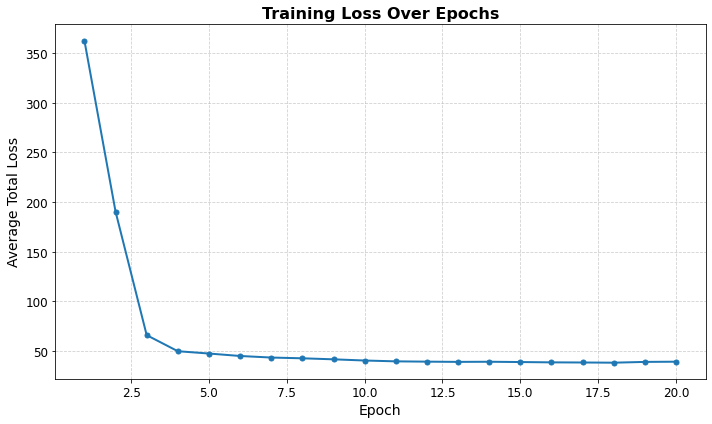

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Use a smooth line with markers
plt.plot(range(1, len(train_losses) + 1), train_losses, color="#1f77b4", linewidth=2, marker='o', markersize=5)

# Grid + labels
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Average Total Loss", fontsize=14)
plt.title("Training Loss Over Epochs", fontsize=16, weight='bold')

# Improve ticks and layout
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()

plt.show()

In [9]:
@torch.no_grad()
def generate_samples(model, train_loader_fmnist, n_samples=10000, refine_steps=3, inference_steps=15, alpha=0.1, beta=3.0):
    model.eval()

    # Pass full training data once to compute empirical mean/std of h2
    all_h2 = []
    for x, _ in train_loader_fmnist:
        x = x.to(device)
        h1 = model.F1(x)
        h2 = model.F2(h1)
        all_h2.append(h2)
    h2_all = torch.cat(all_h2, dim=0)

    h2_mean = h2_all.mean(dim=0)
    h2_std = h2_all.std(dim=0)

    # Sample h2 ~ N(mean, 4 * std)
    h2 = torch.randn((n_samples, h2_mean.shape[0]), device=device) * (4 * h2_std) + h2_mean

    # Decode h2 to x using G2, G1
    h1 = model.G2(h2)
    x = model.G1(h1)

    # Iterative refinement loop (Algorithm 2)
    for _ in range(refine_steps):
        h1, h2 = model.inference(x, steps=inference_steps, alpha=alpha, beta=beta)
        x = model.G1(h1)

    return x

In [ ]:
import torchvision.utils as vutils

samples = generate_samples(model, train_loader_fmnist, n_samples=64).cpu()

grid = vutils.make_grid(samples.view(-1, 1, 28, 28), nrow=8, padding=2, normalize=True)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray')
plt.axis('off')
plt.title("Generated Samples after 20 Epochs (TargetProp)")
plt.show()

In [11]:
@torch.no_grad()
def generate_samples_without_inference(model, train_loader_fmnist, n_samples=10000):
    model.eval()

    # Compute empirical prior for h2
    all_h2 = []
    for x, _ in train_loader_fmnist:
        x = x.to(device)
        h1 = model.F1(x)
        h2 = model.F2(h1)
        all_h2.append(h2)
    h2_all = torch.cat(all_h2, dim=0)

    h2_mean = h2_all.mean(dim=0)
    h2_std = h2_all.std(dim=0)

    # Sample h2 ~ N(mean, 4 * std)
    h2 = torch.randn((n_samples, h2_mean.shape[0]), device=device) * (4 * h2_std) + h2_mean

    # Decode directly without inference
    h1 = model.G2(h2)
    x = model.G1(h1)

    return x


In [12]:
# Generate 64 samples each
samples_with = generate_samples(model, train_loader_fmnist, n_samples=64)
samples_without = generate_samples_without_inference(model, train_loader_fmnist, n_samples=64)

# Plot
import torchvision.utils as vutils

def show_sample_grid(samples, title):
    grid = vutils.make_grid(samples.view(-1, 1, 28, 28), nrow=8, padding=2, normalize=True)
    plt.figure(figsize=(6, 6))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

#show_sample_grid(samples_with.cpu(), "Generated Samples (With Inference)")
#show_sample_grid(samples_without.cpu(), "Generated Samples (Without Inference)")

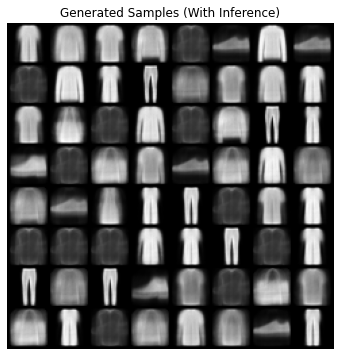

In [13]:
show_sample_grid(samples_with.cpu(), "Generated Samples (With Inference)")

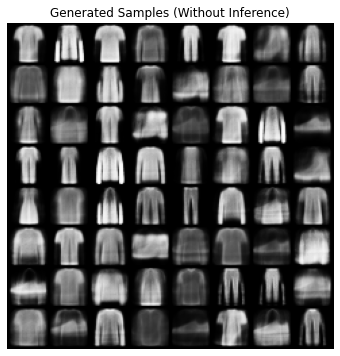

In [14]:
show_sample_grid(samples_without.cpu(), "Generated Samples (Without Inference)")

In [15]:
def log_mean_exp(a):
    max_val, _ = torch.max(a, dim=1, keepdim=True)
    return max_val + torch.log(torch.exp(a - max_val).mean(dim=1, keepdim=True))

def parzen_window_estimator(samples, sigma):
    # samples: (N_samples, D)
    samples = samples.to(device)
    def parzen(x):
        x = x.to(device)
        x = x.unsqueeze(1)  # (B, 1, D)
        samples_exp = samples.unsqueeze(0)  # (1, N, D)
        diffs = (x - samples_exp) / sigma
        e = -0.5 * (diffs ** 2).sum(dim=2)  # (B, N)
        log_probs = log_mean_exp(e) - samples.shape[1] * torch.log(torch.tensor(sigma * np.sqrt(2 * np.pi)))
        return log_probs.squeeze()
    return parzen

In [16]:
@torch.no_grad()
def compute_parzen_log_likelihood(model, train_loader_fmnist, test_loader_fmnist, sigma=0.2, test_batch_size=100):
    model.eval()

    # Generate 10k samples to define the Parzen density
    gen_samples = generate_samples(model, train_loader_fmnist, n_samples=10000)

    # Build Parzen estimator
    parzen = parzen_window_estimator(gen_samples, sigma=sigma)

    # Evaluate in batches
    all_lls = []
    for x, _ in test_loader_fmnist:
        x = x.to(device)
        for i in range(0, x.shape[0], test_batch_size):
            batch = x[i:i+test_batch_size]
            log_probs = parzen(batch)
            all_lls.append(log_probs.cpu())

    all_lls = torch.cat(all_lls, dim=0)
    return all_lls.mean().item()

In [17]:
@torch.no_grad()
def compute_parzen_ll_no_inference(model, train_loader_fmnist, test_loader_fmnist, sigma=0.2, test_batch_size=100):
    model.eval()
    gen_samples = generate_samples_without_inference(model, train_loader_fmnist, n_samples=10000)
    parzen = parzen_window_estimator(gen_samples, sigma=sigma)

    all_lls = []
    for x, _ in test_loader_fmnist:
        x = x.to(device)
        for i in range(0, x.shape[0], test_batch_size):
            batch = x[i:i+test_batch_size]
            log_probs = parzen(batch)
            all_lls.append(log_probs.cpu())

    all_lls = torch.cat(all_lls, dim=0)
    return all_lls.mean().item()


In [18]:
parzen_ll_epochs_fmnist = [1, 5, 10, 15, 20]
parzen_ll_list_fmnist = []
parzen_ll_list_no_infer_fmnist = []

for epoch in parzen_ll_epochs_fmnist:
    checkpoint_file = os.path.join(save_path, f"epoch_{epoch}.pt")
    model.load_state_dict(torch.load(checkpoint_file))
    model.eval()

    # With inference
    ll = compute_parzen_log_likelihood(model, train_loader_fmnist, test_loader_fmnist, sigma=0.2)
    parzen_ll_list_fmnist.append(ll)

    # Without inference
    ll_no = compute_parzen_ll_no_inference(model, train_loader_fmnist, test_loader_fmnist, sigma=0.2)
    parzen_ll_list_no_infer_fmnist.append(ll_no)

    print(f"Epoch {epoch}: Parzen LL (with inference) = {ll:.2f}, without inference = {ll_no:.2f}")


Epoch 1: Parzen LL (with inference) = -276.26, without inference = -50.92
Epoch 5: Parzen LL (with inference) = 106.39, without inference = 222.87
Epoch 10: Parzen LL (with inference) = 183.48, without inference = 268.61
Epoch 15: Parzen LL (with inference) = 201.76, without inference = 279.06
Epoch 20: Parzen LL (with inference) = 206.25, without inference = 285.13


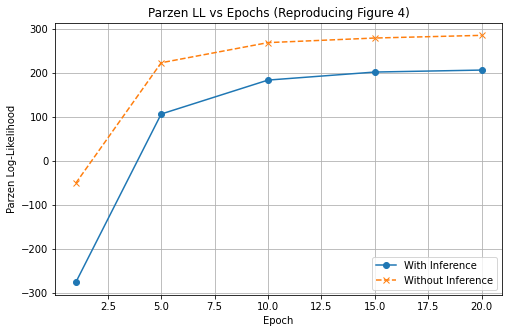

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(parzen_ll_epochs_fmnist, parzen_ll_list_fmnist, label="With Inference", marker='o')
plt.plot(parzen_ll_epochs_fmnist, parzen_ll_list_no_infer_fmnist, label="Without Inference", marker='x', linestyle='--')
plt.xlabel("Epoch")
plt.ylabel("Parzen Log-Likelihood")
plt.title("Parzen LL vs Epochs (Reproducing Figure 4)")
plt.grid(True)
plt.legend()
plt.show()


In [20]:
@torch.no_grad()
def inpaint(model, images, mask, steps=20, alpha=0.1, beta=3.0):
    x_corrupt = images.clone()
    x_corrupt[~mask] = 0  # Zero out the missing part

    x = x_corrupt.clone()
    for _ in range(steps):
        h1, h2 = model.inference(x, steps=1, alpha=alpha, beta=beta)
        x_new = model.G1(h1)
        x[~mask] = x_new[~mask]  # Only update the missing part

    return x_corrupt, x_new

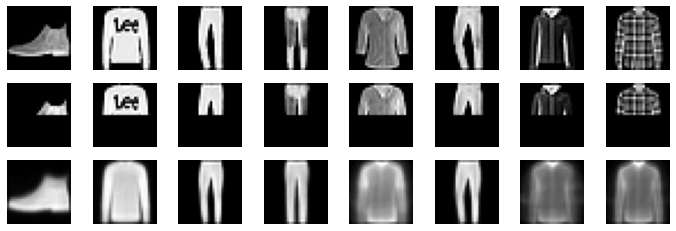

In [21]:
# Get 8 test images
test_images = next(iter(test_loader_fmnist))[0][:8].to(device)

# Create mask: left half = keep, right half = infer
mask = torch.ones_like(test_images).bool()
mask[:, 392:] = False  # pixels 392 to 783 (right half)

# Inpaint
x_corrupt, x_inpainted = inpaint(model, test_images, mask)

# Plot results
def show_images(rows):
    fig, axes = plt.subplots(len(rows), rows[0].shape[0], figsize=(12, 4))
    for i, row in enumerate(rows):
        for j, img in enumerate(row):
            axes[i, j].imshow(img.view(28, 28).cpu(), cmap='gray')
            axes[i, j].axis('off')
    plt.show()

show_images([test_images, x_corrupt, x_inpainted])